In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
Xe_train, Xe_test, ye_train, ye_test = joblib.load(
    "../models/enrollment_data.pkl"
)

Xr_train, Xr_test, yr_train, yr_test = joblib.load(
    "../models/revenue_data.pkl"
)

preprocessor = joblib.load(
    "../models/preprocessor.pkl"
)

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge

In [4]:
enrollment_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestRegressor(
            n_estimators=200,
            random_state=42
        )
    )
])

enrollment_model.fit(
    Xe_train,
    ye_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [5]:
revenue_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        Ridge(alpha=1.0)
    )
])

revenue_model.fit(
    Xr_train,
    yr_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [6]:
result = permutation_importance(
    revenue_model,
    Xr_test,
    yr_test,
    n_repeats=30,
    random_state=42
)

In [7]:
print("Number of raw input features:", len(Xr_test.columns))
print("Number of importances calculated:", len(result.importances_mean))

Number of raw input features: 14
Number of importances calculated: 14


In [8]:
print(Xr_train.columns.tolist())

['CourseCategory', 'CourseType', 'CourseLevel', 'CoursePrice', 'CourseDuration', 'CourseRating', 'Expertise', 'YearsOfExperience', 'PriceBand', 'DurationBucket', 'RatingTier', 'ExperienceBucket', 'ExpertiseMatch', 'LevelEncoded']


In [9]:
feature_names = (
    revenue_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Use the original test dataframe's columns to match the 17 importances
importance_df = pd.DataFrame({
    "Feature": Xr_test.columns,  # <-- Change this from feature_names to your X_test variable
    "Importance": result.importances_mean
})

# Sort them so the most important features are at the top
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Display the top features
print("=== Feature Importances ===")
print(importance_df.to_string(index=False))


=== Feature Importances ===
          Feature  Importance
      CoursePrice    1.444428
        PriceBand    0.016656
       RatingTier    0.001978
      CourseLevel    0.000141
YearsOfExperience    0.000091
        Expertise    0.000005
 ExperienceBucket    0.000000
   CourseDuration   -0.000005
   ExpertiseMatch   -0.000021
   DurationBucket   -0.000393
     LevelEncoded   -0.000477
   CourseCategory   -0.001467
       CourseType   -0.001577
     CourseRating   -0.001699


In [10]:
print(Xr_train.columns.tolist())

['CourseCategory', 'CourseType', 'CourseLevel', 'CoursePrice', 'CourseDuration', 'CourseRating', 'Expertise', 'YearsOfExperience', 'PriceBand', 'DurationBucket', 'RatingTier', 'ExperienceBucket', 'ExpertiseMatch', 'LevelEncoded']


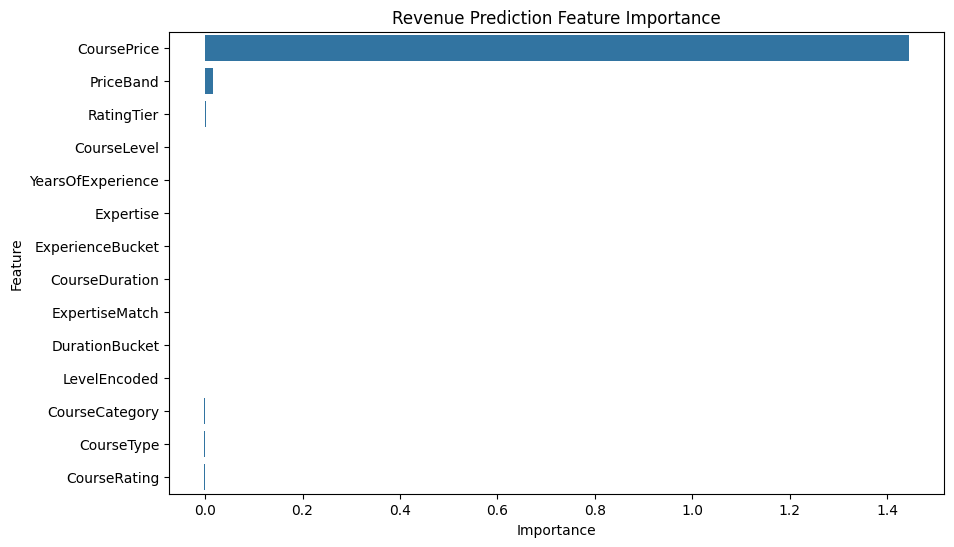

In [11]:
top_features = importance_df.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Revenue Prediction Feature Importance"
)

plt.show()

In [12]:
result_enrollment = permutation_importance(
    enrollment_model,
    Xe_test,
    ye_test,
    n_repeats=30,
    random_state=42
)

In [13]:
# permutation_importance scores the RAW input columns, so align with
# Xe_test.columns (NOT the one-hot-expanded preprocessor names).
enrollment_importance = pd.DataFrame({
    "Feature": Xe_test.columns,
    "Importance": result_enrollment.importances_mean
})

enrollment_importance = (
    enrollment_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

enrollment_importance.head(20)

,Feature,Importance
8,PriceBand,0.163357
10,RatingTier,0.133857
5,CourseRating,0.050381
2,CourseLevel,0.042428
4,CourseDuration,0.023689
9,DurationBucket,0.006853
1,CourseType,0.006553
11,ExperienceBucket,0.000000
3,CoursePrice,-0.000063
7,YearsOfExperience,-0.001668


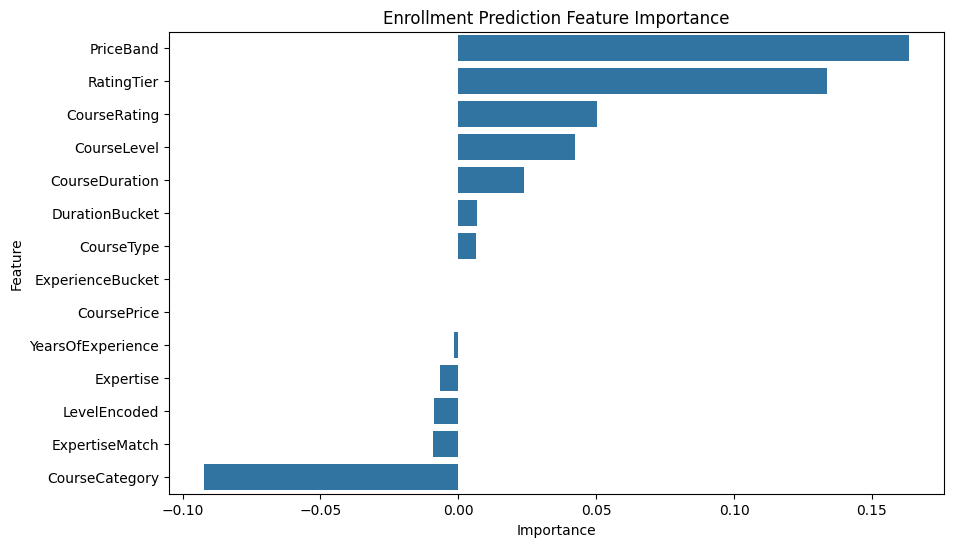

In [14]:
top_features = enrollment_importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Enrollment Prediction Feature Importance"
)

plt.show()

In [15]:
importance_df.to_csv(
    "../data/revenue_feature_importance.csv",
    index=False
)

enrollment_importance.to_csv(
    "../data/enrollment_feature_importance.csv",
    index=False
)

print("Feature importance saved")

Feature importance saved


In [17]:
import streamlit as st

print(st.__version__)

1.58.0
